In [6]:
# Si vous avez déjà téléchargé le dataset avec kagglehub, conservez path tel quel.
import os
import kagglehub

path = kagglehub.dataset_download("ouaraskhelilrafik/tp-02-audio")
print("Path to dataset files:", path)

# Construire le chemin vers l'audio dans "Data/Data/101 - Dog/"
audio_path = os.path.join(path, "Data", "Data", "101 - Dog", "2-116400-A.ogg")
print("Audio file:", audio_path, "| Exists:", os.path.exists(audio_path))


Using Colab cache for faster access to the 'tp-02-audio' dataset.
Path to dataset files: /kaggle/input/tp-02-audio
Audio file: /kaggle/input/tp-02-audio/Data/Data/101 - Dog/2-116400-A.ogg | Exists: True


In [7]:
import os
import numpy as np
import librosa

# ⚠️ Adaptez si besoin : si vous avez déjà audio_path défini, gardez-le.
# Sinon, mettez le chemin absolu vers votre fichier .wav ou .ogg.
# Exemple :
# audio_path = "/content/tp-02-audio/Data/101 - Dog/1-100032-A.ogg"

assert os.path.exists(audio_path), f"Fichier introuvable : {audio_path}"

# sr=None => on conserve la fréquence d'échantillonnage d'origine
y, sr = librosa.load(audio_path, sr=None, mono=True)

# Conserver aussi la version stéréo si vous voulez (non requis ici) :
# y_stereo, sr = librosa.load(audio_path, sr=None, mono=False)


In [8]:
import numpy as np

taille_signal = y.shape[0]
duree_sec = taille_signal / sr

print(f"Taille du signal (échantillons) : {taille_signal}")
print(f"Fréquence d'échantillonnage (Hz) : {sr}")
print(f"Durée (secondes) : {duree_sec:.3f}")


Taille du signal (échantillons) : 220544
Fréquence d'échantillonnage (Hz) : 44100
Durée (secondes) : 5.001


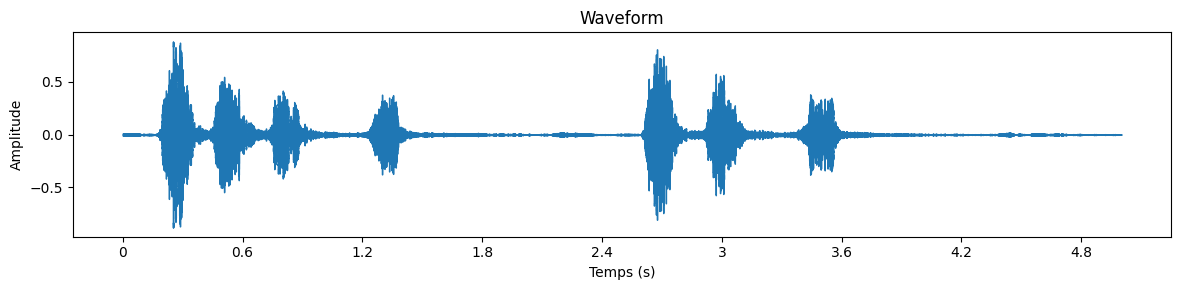

In [9]:
import matplotlib.pyplot as plt
import librosa
import librosa.display

plt.figure(figsize=(12, 3))
librosa.display.waveshow(y, sr=sr)
plt.title("Waveform")
plt.xlabel("Temps (s)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()


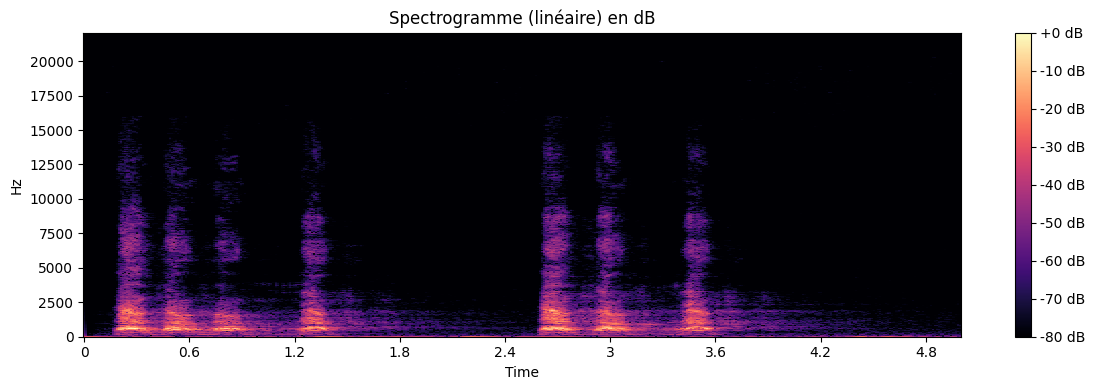

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display

# Paramètres STFT usuels (ajustez si besoin)
n_fft = 2048       # taille de la fenêtre FFT
hop_length = 512   # pas (overlap)
win = "hann"

# STFT -> magnitude
S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length, window=win))

# Convertir en dB
S_db = librosa.amplitude_to_db(S, ref=np.max)

plt.figure(figsize=(12, 4))
librosa.display.specshow(S_db, sr=sr, hop_length=hop_length, x_axis="time", y_axis="linear")
plt.title("Spectrogramme (linéaire) en dB")
plt.colorbar(format="%+2.0f dB")
plt.tight_layout()
plt.show()

# (Optionnel) Spectrogramme mél en dB pour comparaison
# melspec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=128)
# melspec_db = librosa.power_to_db(melspec, ref=np.max)
# plt.figure(figsize=(12, 4))
# librosa.display.specshow(melspec_db, sr=sr, hop_length=hop_length, x_axis="time", y_axis="mel")
# plt.title("Melspectrogramme en dB (optionnel)")
# plt.colorbar(format="%+2.0f dB")
# plt.tight_layout()
# plt.show()


In [11]:
from IPython.display import Audio, display

# Lecture à la fréquence d'échantillonnage d’origine
display(Audio(y, rate=sr))
